### playstore dataset
#### I did the stupidest thing with the data and deleted a row (:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
my_colors = [
    "#0B3C5D",
    "#126E82",
    "#1B98E0",
    "#20B2AA",
    "#2E8B57",
    "#4CAF50"
]

sns.set_theme(
    style="dark",
    palette=my_colors
)

df = pd.read_csv("googleplaystore.csv")

In [2]:
df.head()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
df.shape

(10840, 13)

In [4]:
df.columns

Index(['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type',
       'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver',
       'Android Ver'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10840 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10840 non-null  object 
 1   Category        10840 non-null  object 
 2   Rating          9366 non-null   float64
 3   Reviews         10840 non-null  int64  
 4   Size            10840 non-null  object 
 5   Installs        10840 non-null  object 
 6   Type            10839 non-null  object 
 7   Price           10840 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10840 non-null  object 
 10  Last Updated    10840 non-null  object 
 11  Current Ver     10832 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.1+ MB


In [6]:
df.describe()

,Rating,Reviews
count,9366.000000,1.084000e+04
mean,4.191757,4.441529e+05
std,0.515219,2.927761e+06
min,1.000000,0.000000e+00
25%,4.000000,3.800000e+01
50%,4.300000,2.094000e+03
75%,4.500000,5.477550e+04
max,5.000000,7.815831e+07


### problems:

In [7]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(483)

In [9]:
df.nunique()

App               9659
Category            33
Rating              39
Reviews           6001
Size               461
Installs            21
Type                 2
Price               92
Content Rating       6
Genres             119
Last Updated      1377
Current Ver       2831
Android Ver         33
dtype: int64

### Visualization

In [10]:
df["Category"].value_counts()

Category
FAMILY                 1972
GAME                   1144
TOOLS                   843
MEDICAL                 463
BUSINESS                460
PRODUCTIVITY            424
PERSONALIZATION         392
COMMUNICATION           387
SPORTS                  384
LIFESTYLE               382
FINANCE                 366
HEALTH_AND_FITNESS      341
PHOTOGRAPHY             335
SOCIAL                  295
NEWS_AND_MAGAZINES      283
SHOPPING                260
TRAVEL_AND_LOCAL        258
DATING                  234
BOOKS_AND_REFERENCE     231
VIDEO_PLAYERS           175
EDUCATION               156
ENTERTAINMENT           149
MAPS_AND_NAVIGATION     137
FOOD_AND_DRINK          127
HOUSE_AND_HOME           88
LIBRARIES_AND_DEMO       85
AUTO_AND_VEHICLES        85
WEATHER                  82
ART_AND_DESIGN           65
EVENTS                   64
COMICS                   60
PARENTING                60
BEAUTY                   53
Name: count, dtype: int64

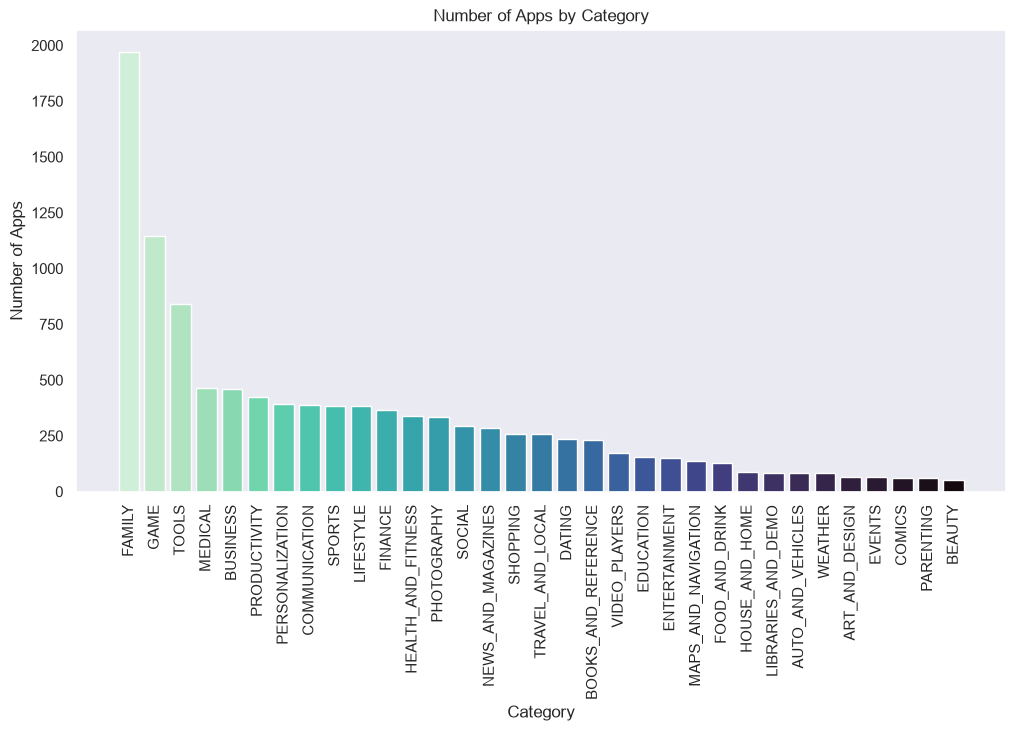

In [11]:
category_counts = df["Category"].value_counts()

plt.figure(figsize=(12, 6))

colors = sns.color_palette(
    "mako_r",
    len(category_counts)
)

plt.bar(category_counts.index, category_counts.values, color=colors)

plt.title("Number of Apps by Category")
plt.xlabel("Category")
plt.ylabel("Number of Apps")

plt.xticks(rotation=90)
plt.show()

In [12]:
df["Rating"].describe()

count    9366.000000
mean        4.191757
std         0.515219
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

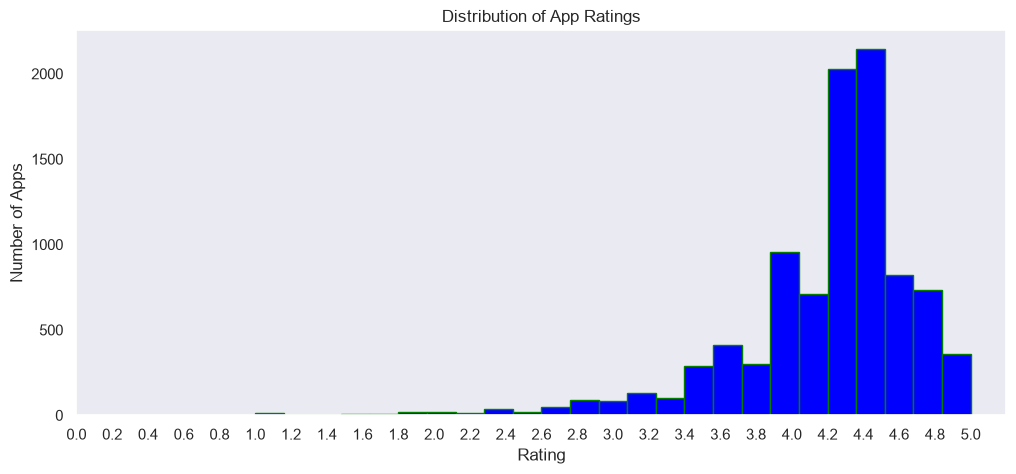

In [13]:
plt.figure(figsize=(12, 5))

plt.hist(df["Rating"].dropna(), bins=25, color='b', edgecolor='g')

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")
plt.xticks(np.arange(0, 5.2, 0.2))

plt.show()

In [14]:
df["Type"].value_counts()

Type
Free    10039
Paid      800
Name: count, dtype: int64

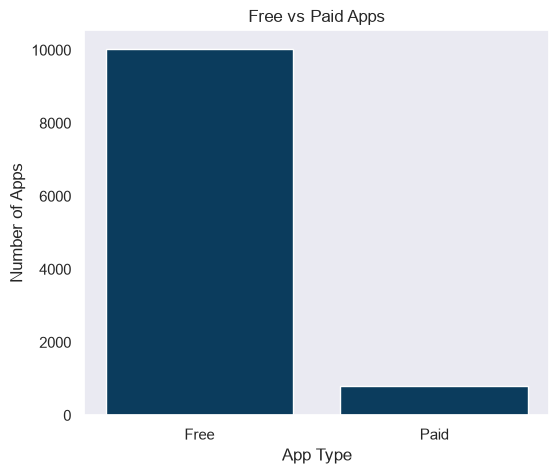

In [15]:
type_counts = df["Type"].value_counts()

plt.figure(figsize=(6, 5))
plt.bar(type_counts.index, type_counts.values)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.show()

In [16]:
df.groupby("Type")["Rating"].mean()

Type
Free    4.186203
Paid    4.266615
Name: Rating, dtype: float64

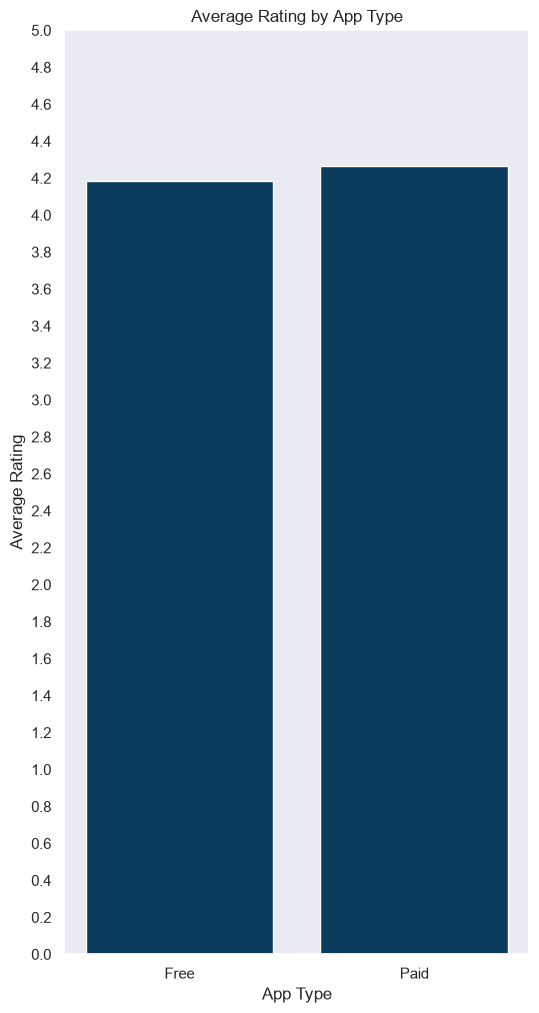

In [17]:
rating_by_type = df.groupby("Type")["Rating"].mean()

plt.figure(figsize=(6, 12))
plt.bar(rating_by_type.index, rating_by_type.values)

plt.title("Average Rating by App Type")
plt.xlabel("App Type")
plt.ylabel("Average Rating")
plt.yticks(np.arange(0, 5.2, 0.2))


plt.show()

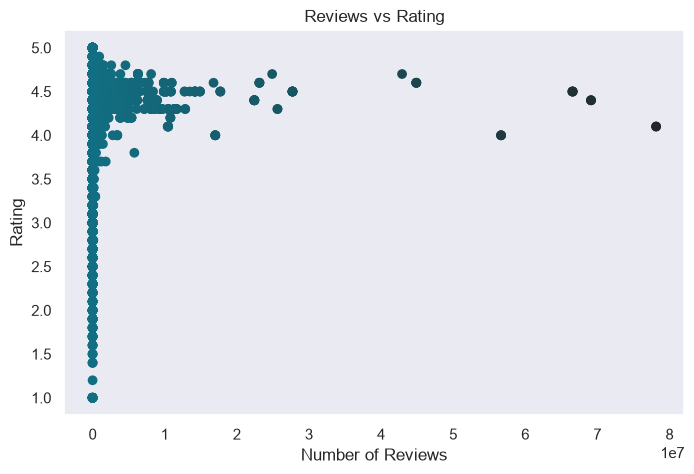

In [18]:
plt.figure(figsize=(8, 5))

colors = sns.dark_palette("#126E82", reverse=True, as_cmap=True)

plt.scatter(df["Reviews"], df["Rating"], c=df["Reviews"], cmap=colors)

plt.title("Reviews vs Rating")
plt.xlabel("Number of Reviews")
plt.ylabel("Rating")

plt.show()

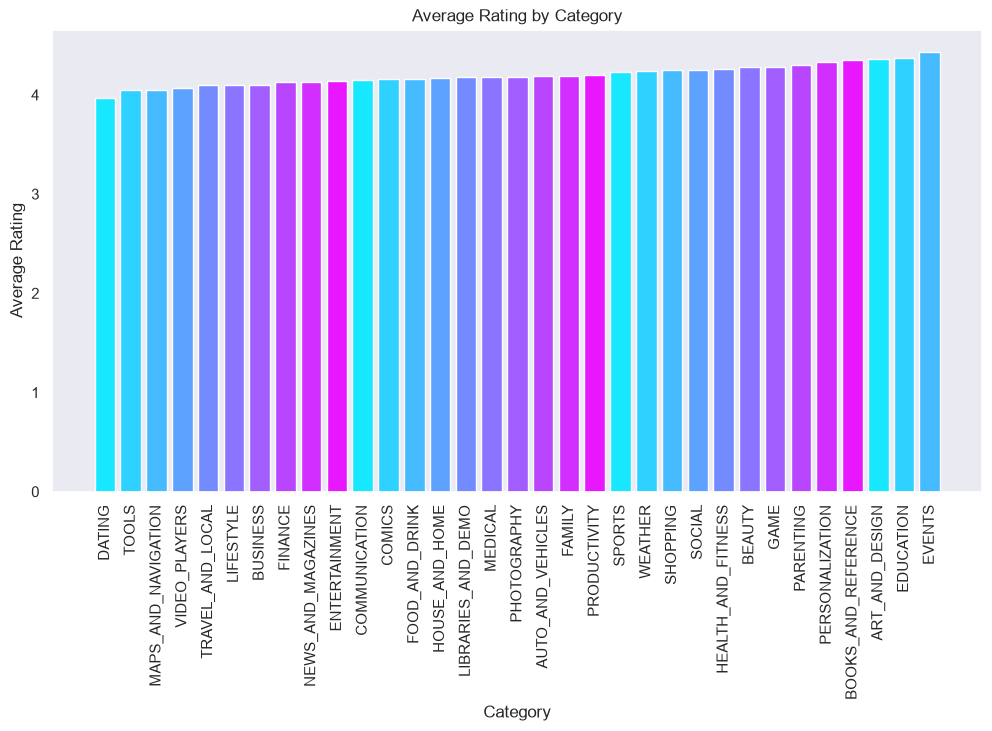

In [62]:
category_rating = df.groupby("Category")["Rating"].mean().sort_values()

plt.figure(figsize=(12, 6))

category_colors = sns.color_palette(
    "cool",
    len(category_counts)
)

plt.bar(category_rating.index, category_rating.values, color=category_colors)

plt.title("Average Rating by Category")
plt.xlabel("Category")
plt.ylabel("Average Rating")

plt.xticks(rotation=90)

plt.show()

## Cleaning


In [20]:
df.isnull().sum()

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

In [21]:
df.duplicated().sum()

np.int64(483)

In [22]:
df = df.drop_duplicates()

In [23]:
df.duplicated().sum()

np.int64(0)

In [24]:
df["Rating"].isnull().sum()

np.int64(1465)

In [25]:
df["Rating"].isnull().mean() * 100

np.float64(14.145022689968137)

In [26]:
df["Reviews"].dtype

dtype('int64')

In [27]:
df["Installs"].dtype

dtype('O')

In [28]:
df["Installs"] = (
    df["Installs"]
    .str.replace(",", "", regex=False)
    .str.replace("+", "", regex=False)
)

In [29]:
df["Installs"] = pd.to_numeric(df["Installs"], errors="coerce")

In [30]:
df["Installs"].dtype

dtype('int64')

In [31]:
df["Price"] = df["Price"].str.replace("$", "", regex=False)

In [32]:
df["Price"] = pd.to_numeric(df["Price"], errors="coerce")

In [33]:
df["Price"].dtype

dtype('float64')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10357 entries, 0 to 10839
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10357 non-null  object 
 1   Category        10357 non-null  object 
 2   Rating          8892 non-null   float64
 3   Reviews         10357 non-null  int64  
 4   Size            10357 non-null  object 
 5   Installs        10357 non-null  int64  
 6   Type            10356 non-null  object 
 7   Price           10357 non-null  float64
 8   Content Rating  10357 non-null  object 
 9   Genres          10357 non-null  object 
 10  Last Updated    10357 non-null  object 
 11  Current Ver     10349 non-null  object 
 12  Android Ver     10355 non-null  object 
dtypes: float64(2), int64(2), object(9)
memory usage: 1.1+ MB


In [35]:
df["Rating"].describe()

count    8892.000000
mean        4.187877
std         0.522377
min         1.000000
25%         4.000000
50%         4.300000
75%         4.500000
max         5.000000
Name: Rating, dtype: float64

In [36]:
df["Rating"].value_counts().sort_index()

Rating
1.0      16
1.2       1
1.4       3
1.5       3
1.6       4
1.7       8
1.8       8
1.9      12
2.0      12
2.1       8
2.2      14
2.3      20
2.4      19
2.5      20
2.6      24
2.7      23
2.8      40
2.9      45
3.0      82
3.1      69
3.2      64
3.3     101
3.4     127
3.5     157
3.6     169
3.7     231
3.8     293
3.9     372
4.0     539
4.1     657
4.2     888
4.3    1016
4.4    1032
4.5     977
4.6     768
4.7     484
4.8     228
4.9      87
5.0     271
Name: count, dtype: int64

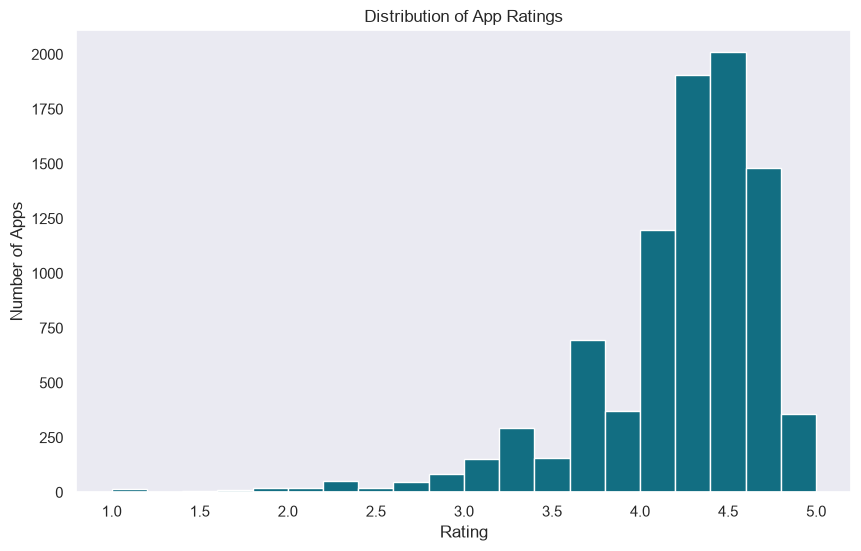

In [37]:
plt.figure(figsize=(10, 6))

plt.hist(df["Rating"].dropna(), bins=20, color="#126E82")

plt.title("Distribution of App Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Apps")

plt.show()

C:\Users\ahmed\AppData\Local\Temp\ipykernel_10872\2211824839.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Rating"].dropna(), vert=False)


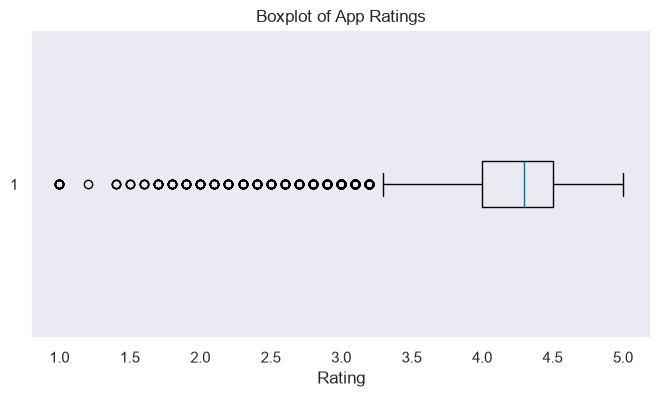

In [38]:
plt.figure(figsize=(8, 4))

plt.boxplot(df["Rating"].dropna(), vert=False)

plt.title("Boxplot of App Ratings")
plt.xlabel("Rating")

plt.show()

## seaborn

In [39]:
my_colors = [
    "#0B3C5D",
    "#126E82",
    "#1B98E0",
    "#20B2AA",
    "#2E8B57",
    "#4CAF50"
]

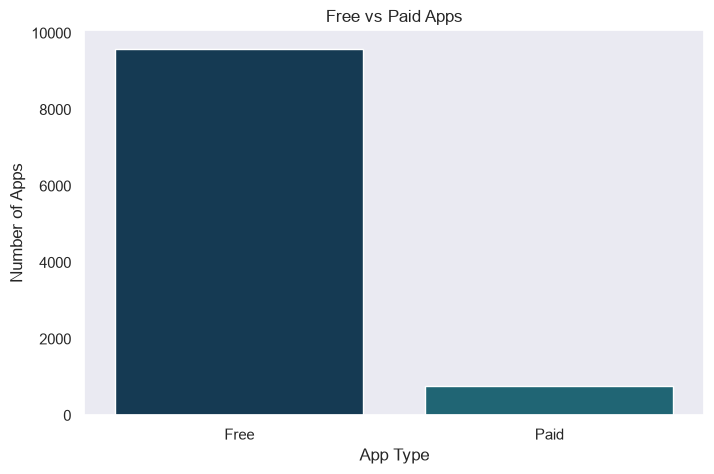

In [40]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Type",
    hue="Type",
    palette=my_colors[:2],
    legend=False
)

plt.title("Free vs Paid Apps")
plt.xlabel("App Type")
plt.ylabel("Number of Apps")

plt.show()

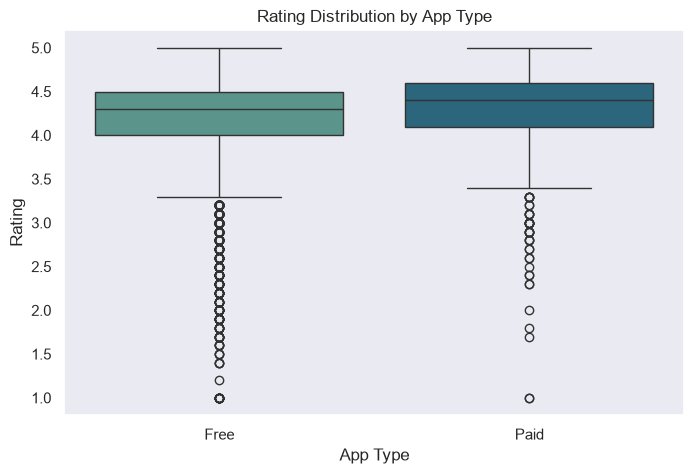

In [41]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Type",
    y="Rating",
    hue="Type",
    palette="crest",
    legend=False
)

plt.title("Rating Distribution by App Type")
plt.xlabel("App Type")
plt.ylabel("Rating")

plt.show()

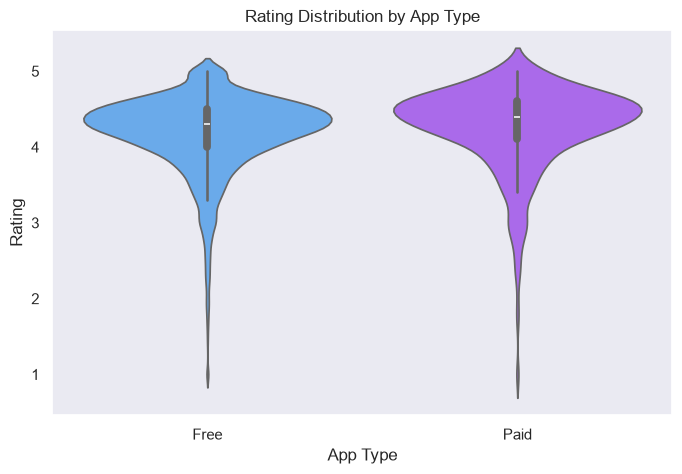

In [42]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    x="Type",
    y="Rating",
    hue="Type",
    palette="cool",
    legend=False
)

plt.title("Rating Distribution by App Type")
plt.xlabel("App Type")
plt.ylabel("Rating")

plt.show()

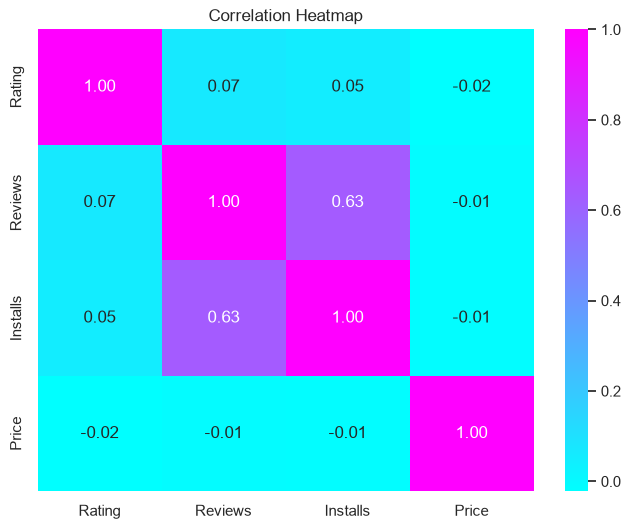

In [43]:
plt.figure(figsize=(8, 6))

numeric_df = df.select_dtypes(include="number")

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="cool",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

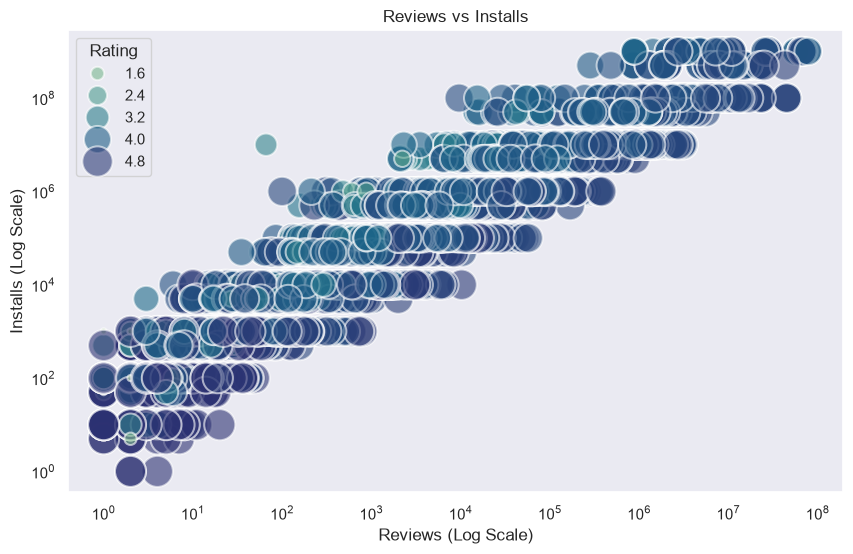

In [44]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Reviews",
    y="Installs",
    size="Rating",
    hue="Rating",
    sizes=(20, 500),
    palette="crest",
    alpha=0.6
)

plt.xscale("log")
plt.yscale("log")

plt.title("Reviews vs Installs")
plt.xlabel("Reviews (Log Scale)")
plt.ylabel("Installs (Log Scale)")

plt.show()

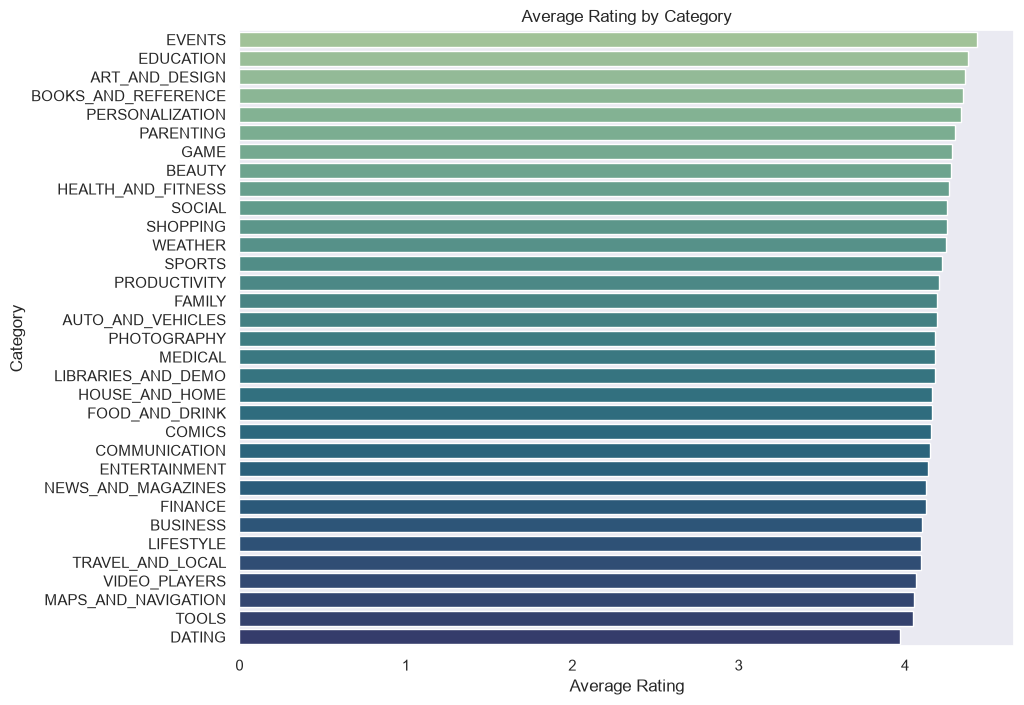

In [45]:
category_rating = (
    df.groupby("Category")["Rating"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 8))

sns.barplot(
    x=category_rating.values,
    y=category_rating.index,
    hue=category_rating.index,
    palette="crest",
    legend=False
)

plt.title("Average Rating by Category")
plt.xlabel("Average Rating")
plt.ylabel("Category")

plt.show()

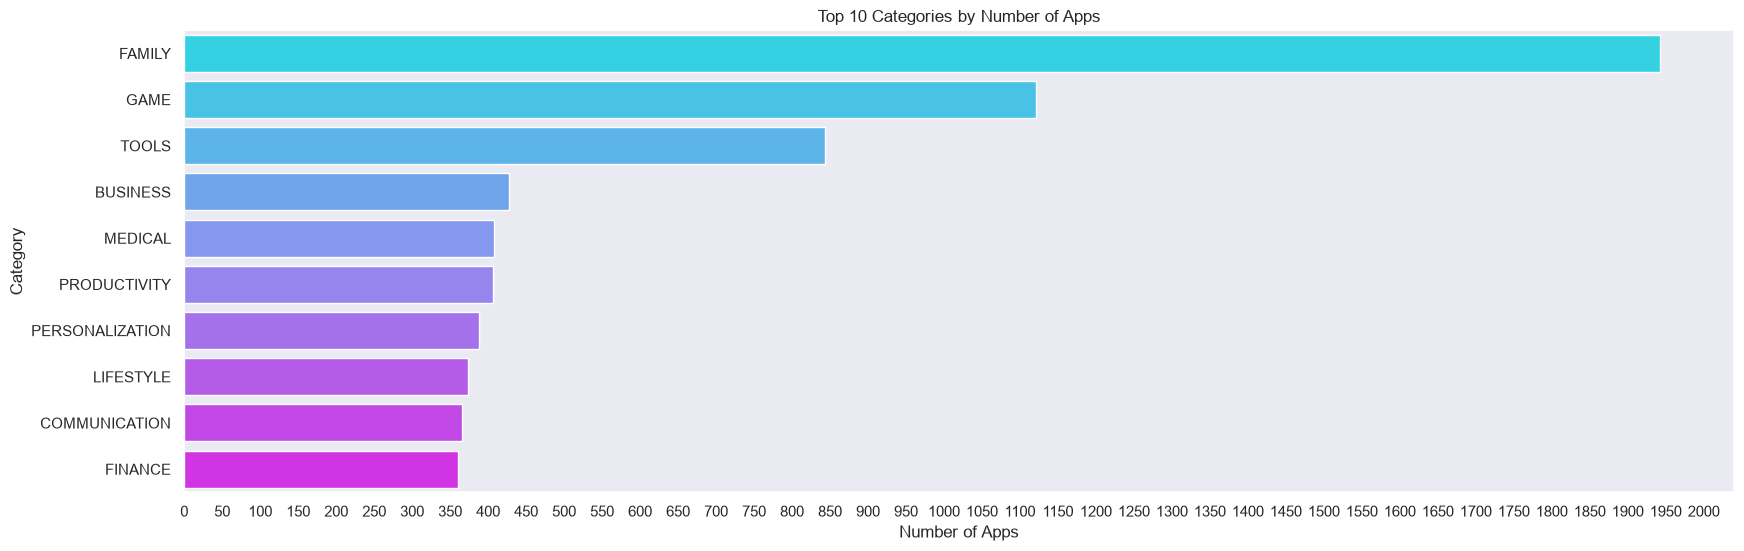

In [46]:
category_counts = df["Category"].value_counts().head(10)

plt.figure(figsize=(20, 6))

sns.barplot(
    x=category_counts.values,
    y=category_counts.index,
    hue=category_counts.index,
    palette="cool",
    legend=False
)

plt.title("Top 10 Categories by Number of Apps")
plt.xlabel("Number of Apps")
plt.ylabel("Category")
plt.xticks(np.arange(0, 2050, 50))

plt.show()

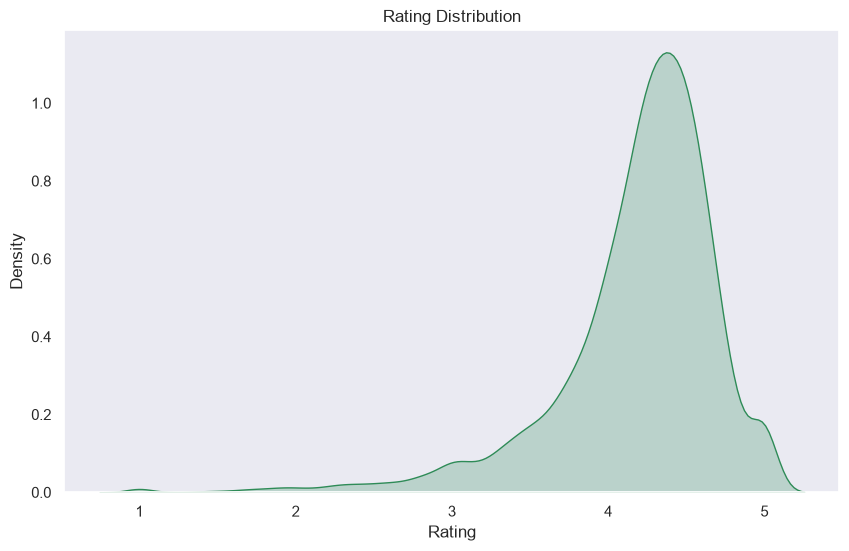

In [47]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x="Rating",
    fill=True,
    color="#2E8B57"
)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Density")

plt.show()

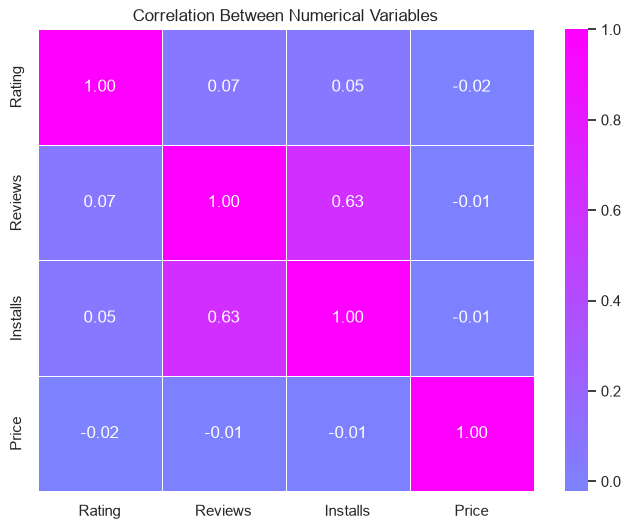

In [48]:
corr = df[
    ["Rating", "Reviews", "Installs", "Price"]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="cool",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Between Numerical Variables")

plt.show()